In [1]:
import pandas as pd
from pandas.tseries.offsets import DateOffset
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata
import datetime as dt
from pathlib import Path
import os
from tqdm import tqdm
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import folium
from branca.colormap import linear
from branca.colormap import LinearColormap
from datetime import datetime
import warnings
from scipy import stats
import matplotlib.cm as cm
import matplotlib.colors as colors
from matplotlib.colors import ListedColormap
from scipy.stats import ttest_ind
from scipy.stats import linregress
import statsmodels.api as sm
from scipy.stats import norm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.regression.mixed_linear_model import MixedLM
import statsmodels.formula.api as smf

In [2]:
def calculate_cohens_d(modelled, observed):
    # Calculate the mean difference
    mean_diff = np.mean(modelled) - np.mean(observed)
    
    # Calculate the pooled standard deviation
    pooled_std = np.sqrt(((np.std(modelled, ddof=1) ** 2 + np.std(observed, ddof=1) ** 2) / 2))
    
    # Calculate Cohen's d
    cohens_d = abs(mean_diff / pooled_std)
    
    return cohens_d

def interpret_cohens_d(d):
    if d < 0.2:
        return "Small effect"
    elif 0.2 <= d < 0.8:
        return "Medium effect"
    else:
        return "Large effect"

In [3]:
#Read in cleaned timeseries of modelled and observed data
dat_all = pd.read_csv('/glade/u/home/demurray/Murray-NCAR-GVP/Data outputs/Precip Filtered Cleaned Paired Modeled Observed Timeseries FINAL.csv',
                      parse_dates = ['dateOnround', 'dateOffround'])
dat_all['Year'] = dat_all['dateOffround'].dt.year
dat_all

,Unnamed: 0,siteId,SamplingInt,dateOnround,dateOffround,latitude,lon,longitude,Modelled,Observed,Variable,Percent_Error,Precip_Percent_Error,year,Error_bin,Error_bin_simple,Month,Year
0,357421,MT97,454.0,2008-10-08,2008-10-16,45.69200,246.25,-113.968000,21.718927,38.35400,Precipitation_mm,76.592515,76.592515,2008,"(75, 100]",3,10,2008
1,337506,MS10,395.0,2007-07-25,2007-08-01,32.30690,270.00,-90.318600,23.683537,8.44400,Precipitation_mm,64.346542,64.346542,2007,"(50, 75]",2,8,2007
2,337510,MS10,399.0,2007-08-22,2007-08-29,32.30690,270.00,-90.318600,20.926037,7.62000,Precipitation_mm,63.586035,63.586035,2007,"(50, 75]",2,8,2007
3,337514,MS10,400.0,2007-08-29,2007-09-05,32.30690,270.00,-90.318600,30.731049,12.70000,Precipitation_mm,58.673717,58.673717,2007,"(50, 75]",2,9,2007
4,337518,MS10,401.0,2007-09-05,2007-09-12,32.30690,270.00,-90.318600,15.338802,14.22400,Precipitation_mm,7.267854,7.267854,2007,"(0, 25]",0,9,2007
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
625287,709633,OR10,131.0,2007-04-18,2007-04-23,44.26664,237.50,-122.177000,2.049685,20.17268,WetDep_DOC_mgm2,884.184224,20.753170,2007,"(0, 25]",0,4,2007
625288,709645,OR10,144.0,2007-07-18,2007-07-23,44.26664,237.50,-122.177000,4.770262,11.17600,WetDep_DOC_mgm2,134.284832,34.961172,2007,"(25, 50]",1,7,2007
625289,709651,OR10,155.0,2007-10-03,2007-10-09,44.26664,237.50,-122.177000,4.802452,29.38780,WetDep_DOC_mgm2,511.933201,277.859467,2007,"(275, 300]",11,10,2007
625290,709655,OR10,157.0,2007-10-16,2007-10-23,44.26664,237.50,-122.177000,10.268088,33.01492,WetDep_DOC_mgm2,221.529376,69.261900,2007,"(50, 75]",2,10,2007


In [4]:
#calculate number data points per variable after precip filter was applied
site_count = dat_all.groupby('Variable')['Modelled'].count()
site_count

Variable
Precipitation_mm    157886
WetDep_DOC_mgm2       2460
WetDep_NH4_mgm2     155016
WetDep_NO3_mgm2     154963
WetDep_SO4_mgm2     154967
Name: Modelled, dtype: int64

In [5]:
#Average all sites per month
dat_all_monyr_sum = dat_all.groupby(['siteId', 'Variable', 'Year', 'Month'])['Modelled', 'Observed'].sum().reset_index()
dat_all_monyr = dat_all_monyr_sum .groupby(['Variable', 'Year', 'Month'])['Modelled', 'Observed'].mean().reset_index()
dat_all_monyr['Yr-Mon'] = pd.to_datetime(dat_all_monyr[['Year', 'Month']].assign(DAY=1))

#Calculate std error
SE_mod = dat_all_monyr.groupby('Variable')[['Modelled', 'Observed']].std().reset_index()
SE_mod = SE_mod.rename(columns = {'Modelled' : 'Mod_SE', 'Observed' : 'Obs_SE'})
dat_all_monyr = pd.merge(dat_all_monyr, SE_mod, on = 'Variable')
dat_all_monyr = dat_all_monyr.loc[dat_all_monyr['Year'] != 2023,]
dat_all_monyr

/glade/derecho/scratch/demurray/tmp/ipykernel_36713/3689639810.py:2: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  dat_all_monyr_sum = dat_all.groupby(['siteId', 'Variable', 'Year', 'Month'])['Modelled', 'Observed'].sum().reset_index()
/glade/derecho/scratch/demurray/tmp/ipykernel_36713/3689639810.py:3: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  dat_all_monyr = dat_all_monyr_sum .groupby(['Variable', 'Year', 'Month'])['Modelled', 'Observed'].mean().reset_index()


,Variable,Year,Month,Modelled,Observed,Yr-Mon,Mod_SE,Obs_SE
0,Precipitation_mm,2002,1,43.239810,42.224404,2002-01-01,14.893685,14.950506
1,Precipitation_mm,2002,2,42.710353,39.309817,2002-02-01,14.893685,14.950506
2,Precipitation_mm,2002,3,70.639942,61.791575,2002-03-01,14.893685,14.950506
3,Precipitation_mm,2002,4,61.598602,58.840848,2002-04-01,14.893685,14.950506
4,Precipitation_mm,2002,5,85.346075,78.196446,2002-05-01,14.893685,14.950506
...,...,...,...,...,...,...,...,...
1236,WetDep_SO4_mgm2,2022,8,21.432637,21.247491,2022-08-01,9.947222,24.330268
1237,WetDep_SO4_mgm2,2022,9,15.640305,14.242994,2022-09-01,9.947222,24.330268
1238,WetDep_SO4_mgm2,2022,10,9.987564,12.679377,2022-10-01,9.947222,24.330268
1239,WetDep_SO4_mgm2,2022,11,13.742270,13.845236,2022-11-01,9.947222,24.330268


In [6]:
#Calculate the difference between mod and obs for each solute and month
dat_all_monyr['Perc_Difference_abs'] = abs((dat_all_monyr['Modelled'] - dat_all_monyr['Observed']/dat_all_monyr['Modelled'])) 
dat_all_monyr['Diff_factor'] = (dat_all_monyr['Observed'] / dat_all_monyr['Modelled']) 

#For Precip:
dat_all_monyr_precip = dat_all_monyr.loc[dat_all_monyr['Variable'] == 'Precipitation_mm',]
dat_all_monyr_precip.to_csv('/glade/u/home/demurray/Murray-NCAR-GVP/Data outputs/Total monthly flux timeseries Precip mod obs.csv')

#Find the mean and stdev of scaling factor
print('Precip')
print(dat_all_monyr_precip['Diff_factor'].mean())
print(dat_all_monyr_precip['Diff_factor'].median())
print(dat_all_monyr_precip['Diff_factor'].std())
print(dat_all_monyr_precip['Diff_factor'].sem())

#For SO4:
dat_all_monyr_SO4 = dat_all_monyr.loc[dat_all_monyr['Variable'] == 'WetDep_SO4_mgm2',]
dat_all_monyr_SO4.to_csv('/glade/u/home/demurray/Murray-NCAR-GVP/Data outputs/Total monthly flux timeseries SO4 mod obs.csv')

#Find the mean and stdev of scaling factor
print('SO4')
print(dat_all_monyr_SO4['Diff_factor'].mean())
print(dat_all_monyr_SO4['Diff_factor'].median())
print(dat_all_monyr_SO4['Diff_factor'].std())
print(dat_all_monyr_SO4['Diff_factor'].sem())

#For NO3:
dat_all_monyr_NO3 = dat_all_monyr.loc[dat_all_monyr['Variable'] == 'WetDep_NO3_mgm2',]
dat_all_monyr_NO3.to_csv('/glade/u/home/demurray/Murray-NCAR-GVP/Data outputs/Total monthly flux timeseries NO3 mod obs.csv')

#Find the mean and stdev of scaling factor
print('NO3')
print(dat_all_monyr_NO3['Diff_factor'].mean())
print(dat_all_monyr_NO3['Diff_factor'].median())
print(dat_all_monyr_NO3['Diff_factor'].std())
print(dat_all_monyr_NO3['Diff_factor'].sem())

#For NH4:
dat_all_monyr_NH4 = dat_all_monyr.loc[dat_all_monyr['Variable'] == 'WetDep_NH4_mgm2',]
dat_all_monyr_NH4.to_csv('/glade/u/home/demurray/Murray-NCAR-GVP/Data outputs/Total monthly flux timeseries NH4 mod obs.csv')

#Find the mean and stdev of scaling factor
print('NH4')
print(dat_all_monyr_NH4['Diff_factor'].mean())
print(dat_all_monyr_NH4['Diff_factor'].median())
print(dat_all_monyr_NH4['Diff_factor'].std())
print(dat_all_monyr_NH4['Diff_factor'].sem())

#For DOC:
dat_all_monyr_DOC = dat_all_monyr.loc[dat_all_monyr['Variable'] == 'WetDep_DOC_mgm2',]
dat_all_monyr_DOC.to_csv('/glade/u/home/demurray/Murray-NCAR-GVP/Data outputs/Total monthly flux timeseries DOC mod obs.csv')

#Find the mean and stdev of scaling factor
print('DOC')
print(dat_all_monyr_DOC['Diff_factor'].mean())
print(dat_all_monyr_DOC['Diff_factor'].median())
print(dat_all_monyr_DOC['Diff_factor'].std())
print(dat_all_monyr_DOC['Diff_factor'].sem())

#all solutes
mon_diff = dat_all_monyr.groupby(['Variable', 'Month']).mean()
mon_diff.to_csv('/glade/u/home/demurray/Murray-NCAR-GVP/Data outputs/Monthly differences flux.csv')


Precip
1.0328650206496206
1.023427204780364
0.0852001035085437
0.0053671020371563885
SO4
1.6493801437495497
1.595035849862757
0.46140587662342314
0.029065838166888774
NO3
0.7953629623855423
0.7972621012990735
0.12277466711913072
0.00773407705942759
NH4
1.6375612930884555
1.6263834466726403
0.28518255794507963
0.01796481253752257
DOC
3.0374247054979002
2.338358322257403
2.4219868111959943
0.15970108101247674


/glade/derecho/scratch/demurray/tmp/ipykernel_36713/1784630152.py:61: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  mon_diff = dat_all_monyr.groupby(['Variable', 'Month']).mean()


/glade/derecho/scratch/demurray/tmp/ipykernel_36713/473989803.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels.strftime('%Y-%m-%d'))#, rotation=45)


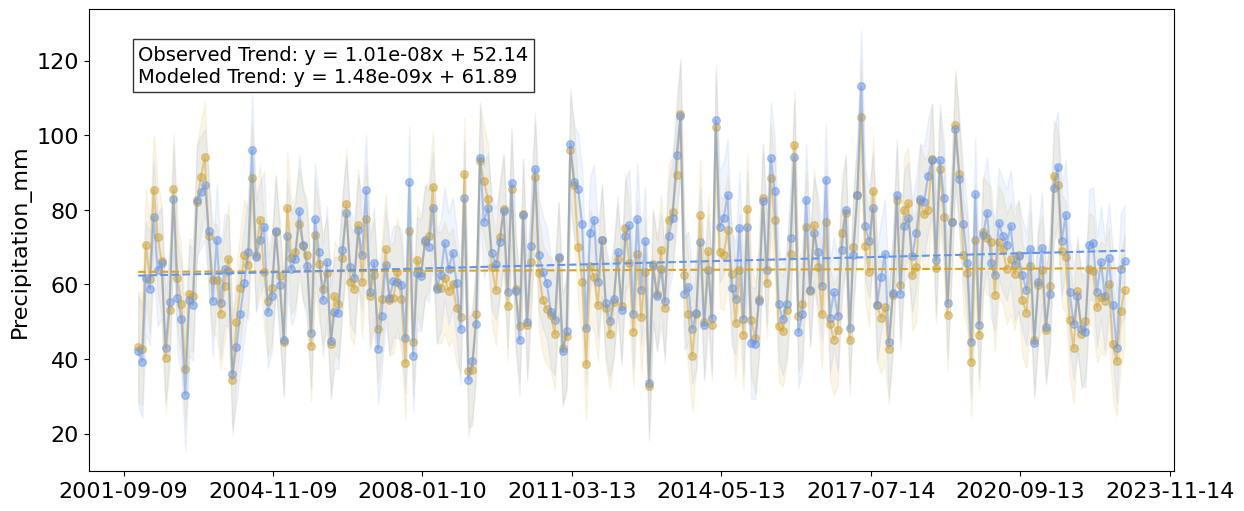

/glade/derecho/scratch/demurray/tmp/ipykernel_36713/473989803.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels.strftime('%Y-%m-%d'))#, rotation=45)


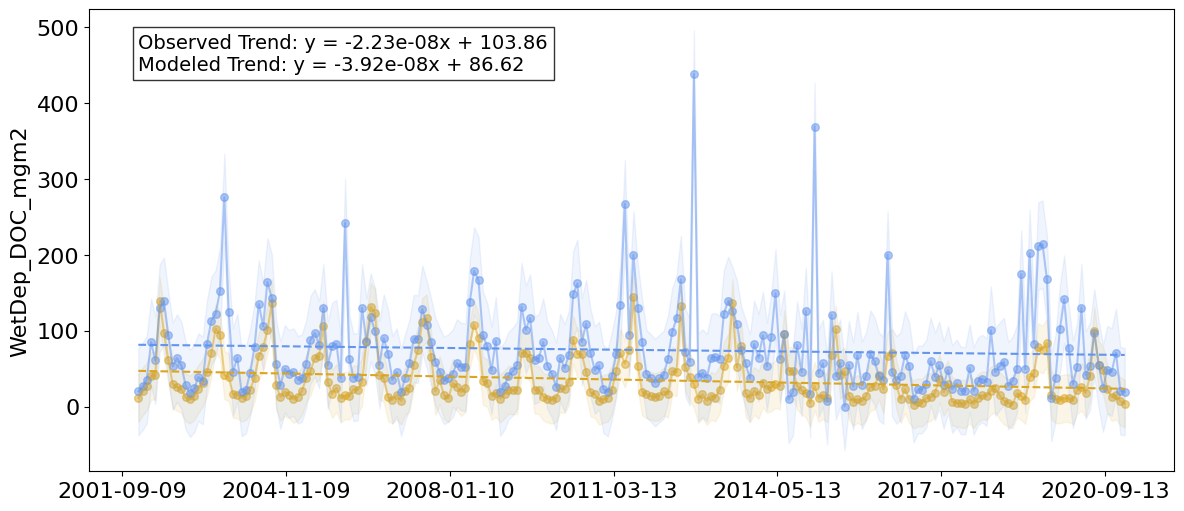

/glade/derecho/scratch/demurray/tmp/ipykernel_36713/473989803.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels.strftime('%Y-%m-%d'))#, rotation=45)


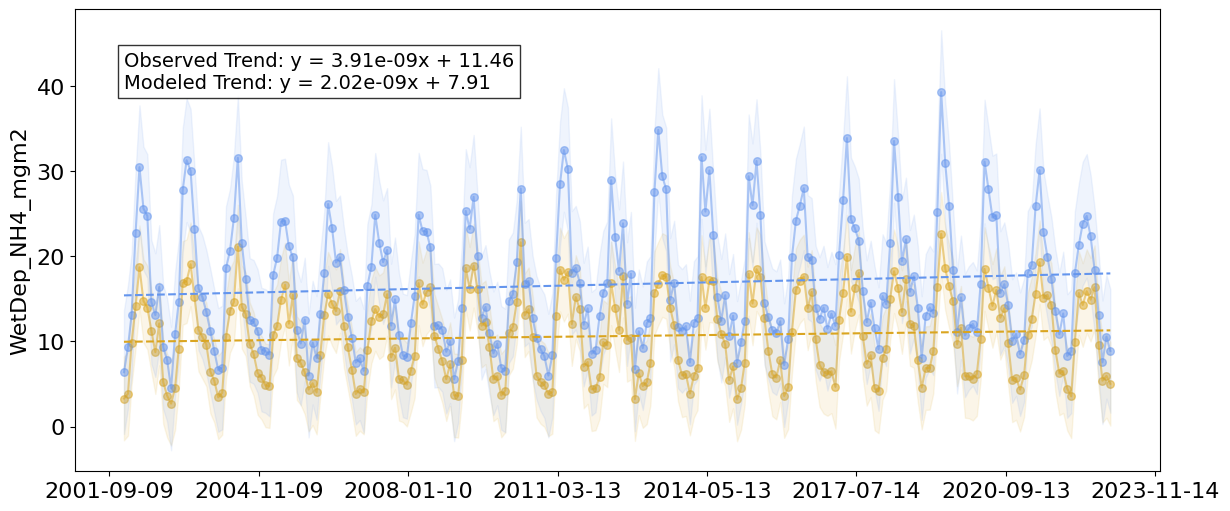

/glade/derecho/scratch/demurray/tmp/ipykernel_36713/473989803.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels.strftime('%Y-%m-%d'))#, rotation=45)


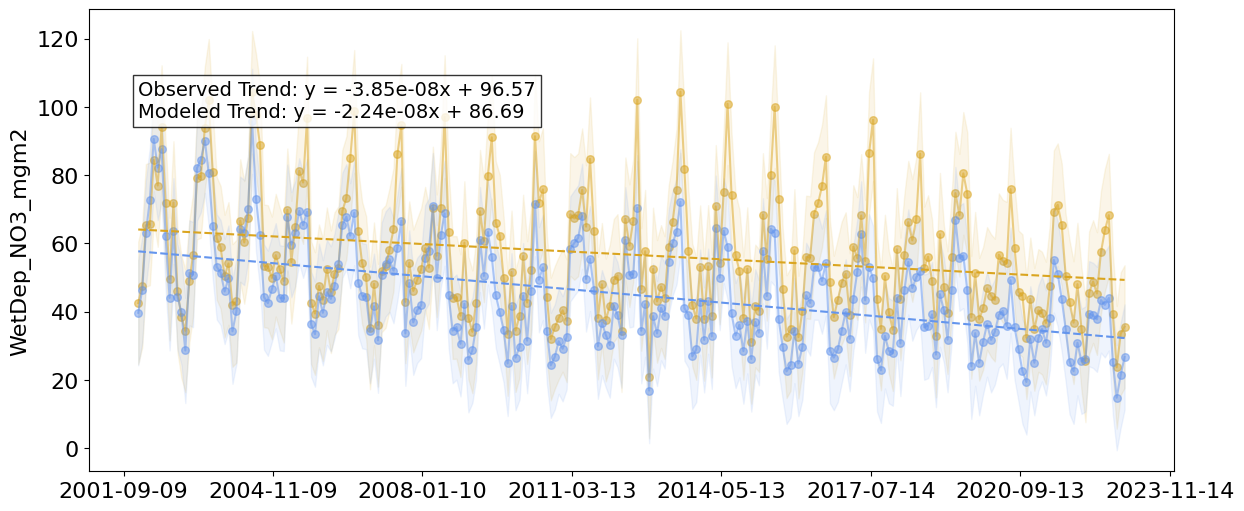

/glade/derecho/scratch/demurray/tmp/ipykernel_36713/473989803.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels.strftime('%Y-%m-%d'))#, rotation=45)


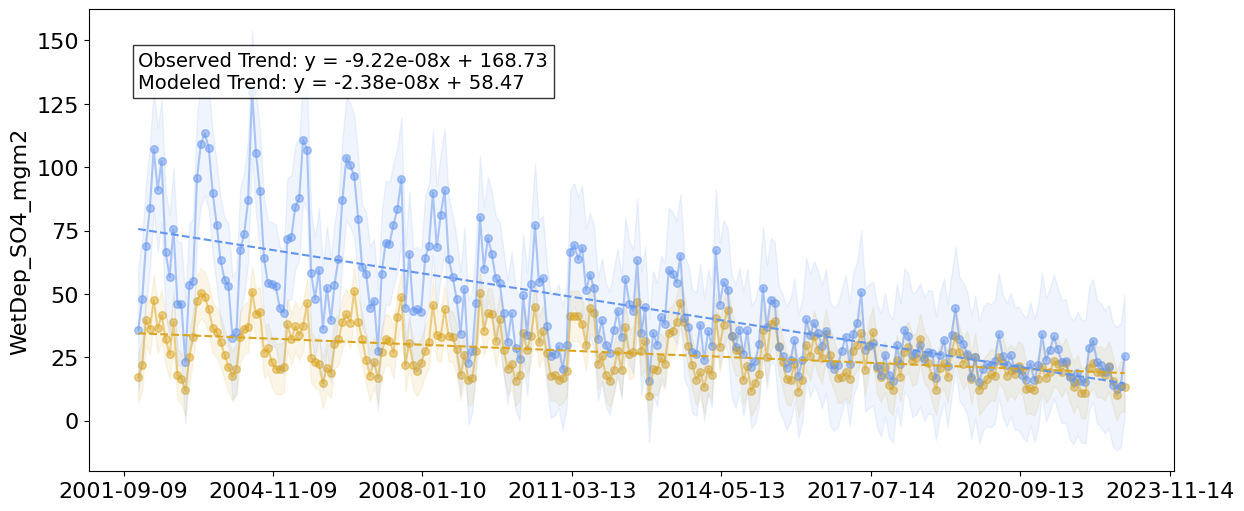

In [7]:
#Plotting a deseasonalized trend
plt.rcParams.update({'font.size': 16})  # Increase text size globally

def plot_deseasonalized_trends(dat_all_monyr):
    for i in dat_all_monyr['Variable'].unique():
        dat_sub = dat_all_monyr.loc[dat_all_monyr['Variable'] == i].copy()

        # Ensure 'Yr-Mon' is in datetime format
        dat_sub['Yr-Mon'] = pd.to_datetime(dat_sub['Yr-Mon'])
        dat_sub.set_index('Yr-Mon', inplace=True)

        # Apply seasonal decomposition (assuming monthly data, period=12)
        decomposition_modelled = seasonal_decompose(dat_sub['Modelled'], model='additive', period=12)
        decomposition_observed = seasonal_decompose(dat_sub['Observed'], model='additive', period=12)

        # Extract deseasonalized data
        dat_sub['Modelled_deseasonalized'] = dat_sub['Modelled'] - decomposition_modelled.seasonal
        dat_sub['Observed_deseasonalized'] = dat_sub['Observed'] - decomposition_observed.seasonal

        # Convert datetime to numeric (Unix timestamp in seconds)
        X_time = dat_sub.index.astype('int64') // 10**9
        X_modelled = sm.add_constant(X_time)
        X_observed = sm.add_constant(X_time)

        # Use deseasonalized values for regression
        y_modelled = dat_sub['Modelled_deseasonalized']
        y_observed = dat_sub['Observed_deseasonalized']

        # Fit OLS models
        model_modelled = sm.OLS(y_modelled, X_modelled).fit()
        model_observed = sm.OLS(y_observed, X_observed).fit()

        # Get regression line values
        trend_modelled = model_modelled.predict(X_modelled)
        trend_observed = model_observed.predict(X_observed)

        # Create the regression plot
        plt.figure(figsize=(14, 6))

        # Plot raw data (points and lines)
        plt.scatter(X_time, dat_sub['Modelled'], color='goldenrod', alpha=0.5, label='Modelled (Raw)', marker='o', s=30)
        plt.plot(X_time, dat_sub['Modelled'], color='goldenrod', alpha=0.5)
        plt.fill_between(X_time, dat_sub['Modelled'] - dat_sub['Mod_SE'], dat_sub['Modelled'] + dat_sub['Mod_SE'],
                         alpha=0.1, edgecolor='goldenrod', facecolor='goldenrod')

        plt.scatter(X_time, dat_sub['Observed'], color='cornflowerblue', alpha=0.5, label='Observed (Raw)', marker='o', s=30)
        plt.plot(X_time, dat_sub['Observed'], color='cornflowerblue', alpha=0.5)
        plt.fill_between(X_time, dat_sub['Observed'] - dat_sub['Obs_SE'], dat_sub['Observed'] + dat_sub['Obs_SE'],
                         alpha=0.1, edgecolor='cornflowerblue', facecolor='cornflowerblue')

        # Plot deseasonalized trend lines
        plt.plot(X_time, trend_modelled, color='goldenrod', linestyle='dashed', label='Modelled (Deseasonalized Trend)')
        plt.plot(X_time, trend_observed, color='cornflowerblue', linestyle='dashed', label='Observed (Deseasonalized Trend)')

        # Add regression equation in the top-left corner
        eq_text = (f'Observed Trend: y = {model_observed.params[1]:.2e}x + {model_observed.params[0]:.2f}\n'
                   f'Modeled Trend: y = {model_modelled.params[1]:.2e}x + {model_modelled.params[0]:.2f}')
        plt.text(X_time.min(), dat_sub['Observed'].max(), eq_text, fontsize=14,
                 bbox=dict(facecolor='white', alpha=0.8), verticalalignment='bottom', horizontalalignment='left')

        # Formatting
       # plt.xlabel("Time", fontsize=16)
        plt.ylabel(i, fontsize=16)
       # plt.legend(loc='upper right', frameon=True, fontsize=14)

        # Format x-axis as dates
        ax = plt.gca()
        new_labels = pd.to_datetime(ax.get_xticks() * 10**9)
        ax.set_xticklabels(new_labels.strftime('%Y-%m-%d'))#, rotation=45)

        plt.savefig(f'/glade/u/home/demurray/External File Uploads/Figures/Precip_Filtered_Monthly_Timeseries_Mod_Obs_{i}.jpg', format='jpg', dpi=300)
        plt.show()

# Call function to generate plots
plot_deseasonalized_trends(dat_all_monyr)


In [8]:
results = []

for i in dat_all_monyr['Variable'].unique():
    dat_sub = dat_all_monyr.loc[dat_all_monyr['Variable'] == i].copy()
    
    # Ensure 'Yr-Mon' is in datetime format
    if not pd.api.types.is_datetime64_any_dtype(dat_sub['Yr-Mon']):
        dat_sub['Yr-Mon'] = pd.to_datetime(dat_sub['Yr-Mon'])
    
    # Set 'Yr-Mon' as the index for time-based regression
    dat_sub.set_index('Yr-Mon', inplace=True)
    
    # Deseasonalize the data
    for y_label in ['Modelled', 'Observed']:
        decomposition = seasonal_decompose(dat_sub[y_label], model='additive', period=12)
        dat_sub[f'{y_label}_Deseasonalized'] = dat_sub[y_label] - decomposition.seasonal
    
    # Prepare the independent variable
    X = sm.add_constant(dat_sub.index.astype('int64') // 10**9)  # Convert datetime to Unix timestamp
    
    # Dictionary to store results for comparison
    comparison = {'Variable': i}
    
    slopes = {}
    slope_ses = {}
    conf_intervals = {}
    
    # Loop over both 'Modelled' and 'Observed'
    for y_label in ['Modelled', 'Observed']:
        y = dat_sub[f'{y_label}_Deseasonalized']
        
        # Fit the model
        model = sm.OLS(y, X).fit()
        
        # Store regression results
        comparison[f'{y_label}_Intercept'] = model.params[0]
        comparison[f'{y_label}_Slope'] = model.params[1]
        comparison[f'{y_label}_Intercept_SE'] = model.bse[0]
        comparison[f'{y_label}_Slope_SE'] = model.bse[1]
        
        # Calculate confidence intervals
        conf_int = model.conf_int(alpha=0.05)
        comparison[f'{y_label}_Intercept_CI'] = (conf_int.iloc[0, 0], conf_int.iloc[0, 1])
        comparison[f'{y_label}_Slope_CI'] = (conf_int.iloc[1, 0], conf_int.iloc[1, 1])
        
        # Store for overlap comparison
        slopes[y_label] = model.params[1]
        slope_ses[y_label] = model.bse[1]
        conf_intervals[y_label] = (conf_int.iloc[1, 0], conf_int.iloc[1, 1])
    
    # Determine overlap categorization for slopes
    model_ci = conf_intervals['Modelled']
    obs_ci = conf_intervals['Observed']
    if model_ci[1] >= obs_ci[0] and obs_ci[1] >= model_ci[0]:
        comparison['Slope_CI_Overlap'] = 'Yes'
    else:
        comparison['Slope_CI_Overlap'] = 'No'
    
    # Calculate Z-score for slope comparison
    slope_diff = slopes['Modelled'] - slopes['Observed']
    slope_se_combined = np.sqrt(slope_ses['Modelled']**2 + slope_ses['Observed']**2)
    z_score_slope = slope_diff / slope_se_combined
    comparison['Slope_Z_Score'] = z_score_slope
    comparison['Slope_p_value'] = 2 * (1 - norm.cdf(abs(z_score_slope)))
    
    # Append the comparison results to the list
    results.append(comparison)

# Convert the list of results to a DataFrame
results_df = pd.DataFrame(results)

# Display the DataFrame
results_df



,Variable,Modelled_Intercept,Modelled_Slope,Modelled_Intercept_SE,Modelled_Slope_SE,Modelled_Intercept_CI,Modelled_Slope_CI,Observed_Intercept,Observed_Slope,Observed_Intercept_SE,Observed_Slope_SE,Observed_Intercept_CI,Observed_Slope_CI,Slope_CI_Overlap,Slope_Z_Score,Slope_p_value
0,Precipitation_mm,61.890693,1.475343e-09,5.721795,4.227717e-09,"(50.62162592633263, 73.15975956277032)","(-6.851138115825817e-09, 9.801823712730666e-09)",52.135126,1.013556e-08,5.694174,4.207307e-09,"(40.920459847289784, 63.3497917774903)","(1.8492784886507395e-09, 1.8421848981789797e-08)",Yes,-1.451966,0.146511
1,WetDep_DOC_mgm2,86.617948,-3.923029e-08,8.382494,6.338551e-09,"(70.10088852650574, 103.13500818771121)","(-5.1719919402464e-08, -2.6740662875489273e-08)",103.862652,-2.226456e-08,25.924657,1.960333e-08,"(52.78010711535627, 154.9451972725825)","(-6.089141346789407e-08, 1.636228729095732e-08)",Yes,-0.823475,0.410238
2,WetDep_NH4_mgm2,7.913638,2.024015e-09,0.782451,5.781367e-10,"(6.372602142929104, 9.45467304538154)","(8.853760757553275e-10, 3.1626546614349446e-09)",11.458060,3.905636e-09,1.289744,9.529652e-10,"(8.917911196931538, 13.998208658361317)","(2.0287721740935735e-09, 5.782499127159705e-09)",Yes,-1.688122,0.091388
3,WetDep_NO3_mgm2,86.690248,-2.238374e-08,4.118796,3.043294e-09,"(78.57828539791679, 94.80221067457411)","(-2.8377505476296988e-08, -1.6389981899600762e...",96.570668,-3.850445e-08,3.522074,2.602388e-09,"(89.63394860636879, 103.50738792318583)","(-4.3629853193803e-08, -3.3379055186277075e-08)",No,4.025895,0.000057
4,WetDep_SO4_mgm2,58.474463,-2.375147e-08,2.438724,1.801923e-09,"(53.671399490509565, 63.27752582857597)","(-2.7300356418396445e-08, -2.0202587907099458e...",168.728569,-9.219801e-08,5.190116,3.834869e-09,"(158.50664494328518, 178.95049324626288)","(-9.975077842370202e-08, -8.464524080864962e-08)",No,16.154041,0.000000


In [9]:
#calculate max value for each variable
maxvals = dat_all.groupby('Variable')[['Modelled', 'Observed']].max()
maxvals

,Modelled,Observed
Variable,,
Precipitation_mm,589.750647,558.038000
WetDep_DOC_mgm2,114.408490,1107.645000
WetDep_NH4_mgm2,41.749708,235.177584
WetDep_NO3_mgm2,237.199165,315.163200
WetDep_SO4_mgm2,216.501053,542.173922


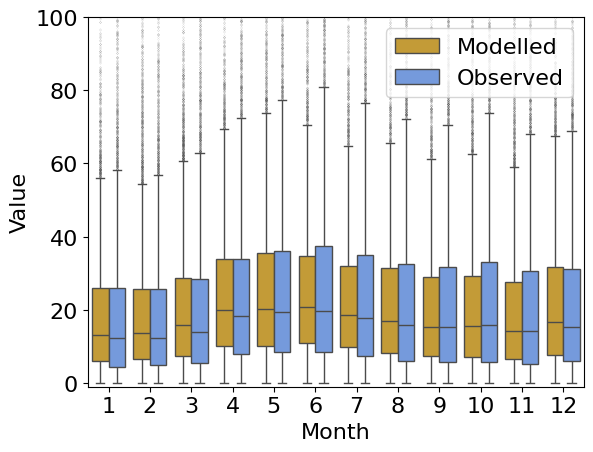

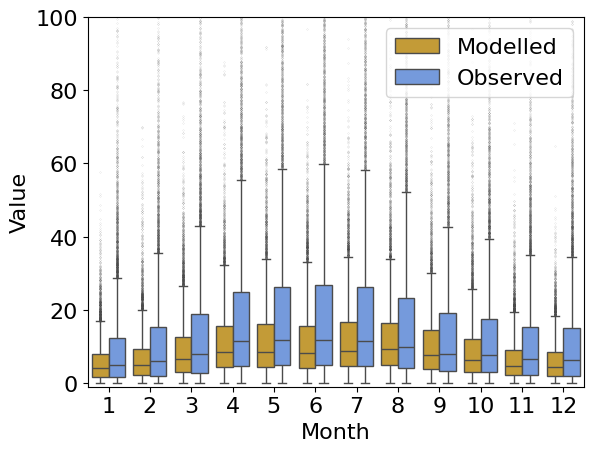

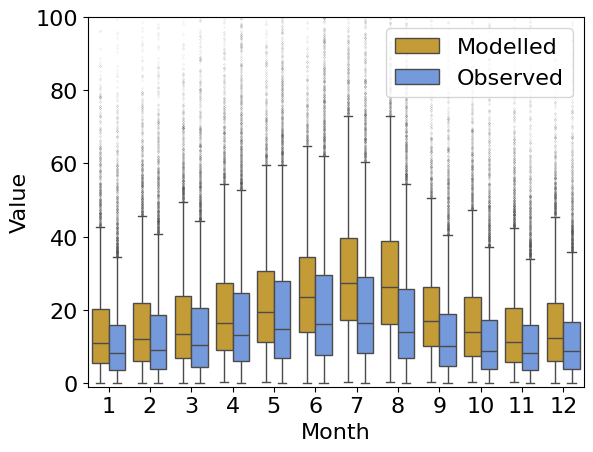

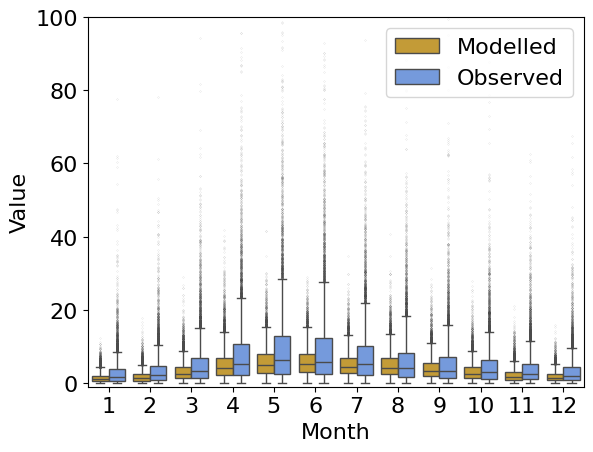

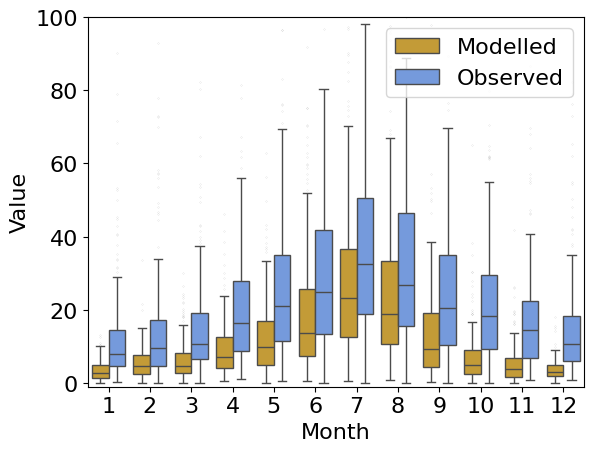

In [13]:
#Boxplot of modelled and observed by month
my_pal = { "Observed": "cornflowerblue", "Modelled": "goldenrod"}

for i in dat_all['Variable'].unique():
    #print(i)
    df = dat_all.loc[dat_all['Variable'] == i,]
    df_long = pd.melt(df,  id_vars=['siteId', 'dateOnround', 'dateOffround', 'latitude', 'lon', 'longitude', 'Percent_Error', 'Month', 'Variable'],
    value_vars=['Modelled', 'Observed'],var_name='Measurement')
    sns.boxplot(data = df_long, x = 'Month', y = 'value', hue = 'Measurement', fliersize=0.05, palette = my_pal)
    plt.ylabel('Value')
    #plt.title(i)
    plt.ylim(-1,100) #put limit to 35 for NH4 plot, limit 80 for sulfate, all others 100 limit
    plt.legend(bbox_to_anchor=(1, 1), loc='upper right')
    plt.savefig(f'/glade/u/home/demurray/External File Uploads/Figures/Precip Filtered Boxplot Monthly Obs Model Values CLEAN {i}.jpg', format='jpg', dpi=300)  # Adjust quality as needed (0 to 100)
    plt.show()

In [11]:
#Conduct a students t-test for each site and solute by month
results = []

# Group by 'Variable' and 'Month' and apply the t-test, Cohen's d, and effect size classification
for (variable, month), group in dat_all.groupby(['Variable', 'Month']):
    t_stat, p_value = stats.ttest_ind(group['Modelled'], group['Observed'])
    d = calculate_cohens_d(group['Modelled'], group['Observed'])
    effect_size = interpret_cohens_d(d)
    
    results.append({
        'Variable': variable,
        'Month': month,
        't_stat': t_stat,
        'p_value': p_value,
        'cohens_d': d,
        'effect_size': effect_size
    })

# Convert the results list to a DataFrame
results_df = pd.DataFrame(results)

# Display the results
print(results_df)
results_df.to_csv('/glade/u/home/demurray/Murray-NCAR-GVP/Data outputs/Monthly Mod Obs T Test Cohens significance.csv')

            Variable  Month     t_stat        p_value  cohens_d    effect_size
0   Precipitation_mm      1   0.046501   9.629110e-01  0.000570   Small effect
1   Precipitation_mm      2   1.718119   8.578652e-02  0.021055   Small effect
2   Precipitation_mm      3   0.661995   5.079795e-01  0.007788   Small effect
3   Precipitation_mm      4   1.136054   2.559439e-01  0.013701   Small effect
4   Precipitation_mm      5  -0.808379   4.188795e-01  0.009854   Small effect
5   Precipitation_mm      6  -3.933792   8.383067e-05  0.048510   Small effect
6   Precipitation_mm      7  -5.792026   7.037574e-09  0.073285   Small effect
7   Precipitation_mm      8  -2.787644   5.313318e-03  0.035385   Small effect
8   Precipitation_mm      9  -6.517968   7.271282e-11  0.085084   Small effect
9   Precipitation_mm     10  -7.107185   1.215507e-12  0.089042   Small effect
10  Precipitation_mm     11  -3.758641   1.712186e-04  0.047003   Small effect
11  Precipitation_mm     12   1.396395   1.626065e-0

In [12]:
#Create difference factors based on all precip cleaned data (using median)
dat_all['Diff_factor'] = (dat_all['Observed'] / dat_all['Modelled']) 

#For Precip:
dat_all_precip = dat_all.loc[dat_all['Variable'] == 'Precipitation_mm',]

#Find the mean and stdev of scaling factor
print('Precip')
print(dat_all_precip['Diff_factor'].median())
print(dat_all_precip['Diff_factor'].std())


#For SO4:
dat_all_SO4 = dat_all.loc[dat_all['Variable'] == 'WetDep_SO4_mgm2',]

#Find the mean and stdev of scaling factor
print('SO4')
print(dat_all_SO4['Diff_factor'].median())
print(dat_all_SO4['Diff_factor'].std())

#For NO3:
dat_all_NO3 = dat_all.loc[dat_all['Variable'] == 'WetDep_NO3_mgm2',]

#Find the mean and stdev of scaling factor
print('NO3')
print(dat_all_NO3['Diff_factor'].median())
print(dat_all_NO3['Diff_factor'].quantile(0.95))

#For NH4:
dat_all_NH4 = dat_all.loc[dat_all['Variable'] == 'WetDep_NH4_mgm2',]
dat_all_NH4 = dat_all_NH4[~dat_all_NH4.isin([np.inf, -np.inf]).any(axis=1)]
dat_all_NH4 = dat_all_NH4.dropna()

#Find the mean and stdev of scaling factor
print('NH4')
print(dat_all_NH4['Diff_factor'].median())
print(dat_all_NH4['Diff_factor'].quantile(0.95))


#For DOC:
dat_all_DOC = dat_all.loc[dat_all['Variable'] == 'WetDep_DOC_mgm2',]

#Find the mean and stdev of scaling factor
print('DOC')
print(dat_all_DOC['Diff_factor'].median())

Precip
0.9487890574324176
0.9772948695512541
SO4
1.292706673686785
8.464267789534317
NO3
0.7055523920180303
2.4367633852590065
NH4
1.2954973861815655
5.870406766798313
DOC
2.259072021435742
